# РГР2 МатСтат
## Вариант 4-A
## В команде: Криличевский Максим, Ситдиков Рафаэль

**4.2. Проверка гипотезы о равенстве математических ожиданий для двух независимых выборок**

Постановка задачи (согласно п. 4.1):

* Нулевая гипотеза ($H_0$): $EX_1 = EX_2$ (математические ожидания выборок равны).  
* Альтернативная гипотеза ($H_1$): $EX_1 \neq EX_2$ (математические ожидания не равны, двусторонняя альтернатива).  
* Уровень значимости: $\alpha = 0.05$.  
* Выбранный критерий: Параметрический t-критерий Стьюдента для двух независимых выборок.  
* Ошибка I рода: Ситуация, при которой мы сделаем вывод о наличии существенных различий между средними значениями выборок, когда на самом деле они статистически равны.  

In [ ]:
from google.colab import files
import pandas as pd
import io

# 1. Запуск окна выбора файла
print("Пожалуйста, выберите файл 'RGR2_A-4_X1-X4.csv' с вашего компьютера:")
uploaded = files.upload()

# 2. Чтение загруженного файла
# uploaded — это словарь, где ключ — имя файла, а значение — его содержимое
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=';')

# Проверка загрузки
print(f"\nФайл '{file_name}' успешно загружен!")
print(f"Объем выборки: {len(df)} строк")
df.head()

Пожалуйста, выберите файл 'RGR2_A-4_X1-X4.csv' с вашего компьютера:


Saving RGR2_A-4_X1-X4.csv to RGR2_A-4_X1-X4.csv

Файл 'RGR2_A-4_X1-X4.csv' успешно загружен!
Объем выборки: 106 строк


,X1,X2,X3,X4
0,68.73,77.57,100.17,2.19
1,80.23,70.55,89.03,4.95
2,81.83,67.01,95.71,1.56
3,83.11,79.59,99.19,23.50
4,71.90,79.58,102.36,21.82


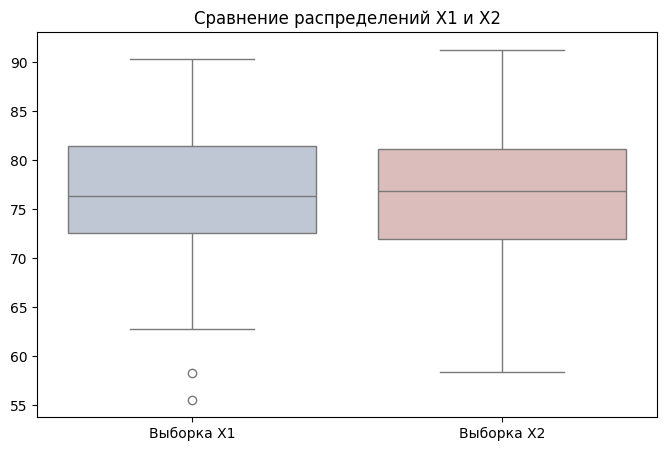

Результаты проверки (t-test):
Наблюдаемое значение t-статистики: 0.3593
p-value: 0.7197
Вывод: p-value >= 0.05 => Нет оснований отвергать H0. Средние статистически равны.


In [ ]:
# Код для вычислений и графиков 4.2
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
df = pd.read_csv('RGR2_A-4_X1-X4.csv', sep=';')
x1, x2 = df['X1'], df['X2']
alpha = 0.05

# Визуализация для обоснования
plt.figure(figsize=(8, 5))
sns.boxplot(data=[x1, x2], palette="vlag")
plt.xticks([0, 1], ['Выборка X1', 'Выборка X2'])
plt.title('Сравнение распределений X1 и X2')
plt.show()

# Расчет критерия
t_stat, p_val_42 = stats.ttest_ind(x1, x2)

print(f"Результаты проверки (t-test):")
print(f"Наблюдаемое значение t-статистики: {t_stat:.4f}")
print(f"p-value: {p_val_42:.4f}")

if p_val_42 < alpha:
    print(f"Вывод: p-value < {alpha} => H0 отвергается. Средние значения различаются.")
else:
    print(f"Вывод: p-value >= {alpha} => Нет оснований отвергать H0. Средние статистически равны.")

**4.3. Проверка гипотезы о параметре нормального распределения. ($X_3$)Постановка задачи (согласно п. 4.1):**

* Нулевая гипотеза ($H_0$): $\sigma^2 = 56.28$ (дисперсия выборки $X_3$ соответствует заданному значению).
* Альтернативная гипотеза ($H_1$): $\sigma^2 \neq 56.28$ (дисперсия значимо отличается от 56.28).
* Уровень значимости: $\alpha = 0.05$.*
* Выбранный критерий: Критерий Хи-квадрат ($\chi^2$) для проверки гипотезы о дисперсии нормальной совокупности.
* Ошибка I рода: Мы ошибочно решим, что точность процесса (дисперсия) изменилась, хотя она осталась на уровне 56.28.

--- Проверка гипотезы о дисперсии X3 ---


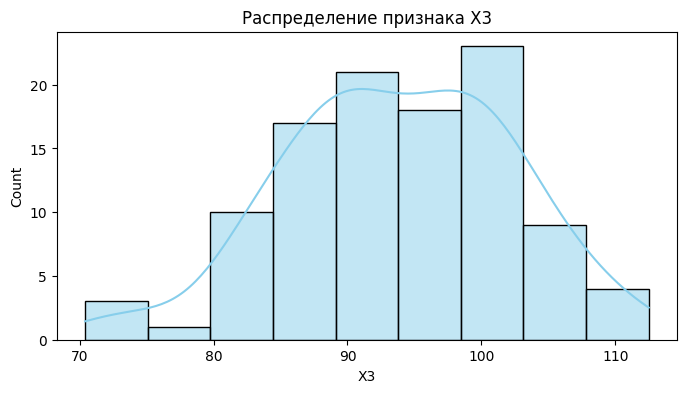

Выборочная дисперсия s^2: 73.1315
Наблюдаемое значение статистики chi2: 136.4394
p-value: 0.0424
Вывод: p-value < 0.05 => H0 отвергается. Дисперсия значимо отличается от 56.28.


In [ ]:
# Код для вычислений и графиков 4.3
print("--- Проверка гипотезы о дисперсии X3 ---")
x3 = df['X3']
n = len(x3)
sigma0_sq = 56.28
s_sq = x3.var(ddof=1) # исправленная выборочная дисперсия

# Визуализация распределения X3
plt.figure(figsize=(8, 4))
sns.histplot(x3, kde=True, color="skyblue")
plt.title('Распределение признака X3')
plt.show()

# Расчет статистики хи-квадрат
chi2_stat = (n - 1) * s_sq / sigma0_sq
# Двустороннее p-value
p_val_43 = 2 * min(stats.chi2.cdf(chi2_stat, n - 1), 1 - stats.chi2.cdf(chi2_stat, n - 1))

print(f"Выборочная дисперсия s^2: {s_sq:.4f}")
print(f"Наблюдаемое значение статистики chi2: {chi2_stat:.4f}")
print(f"p-value: {p_val_43:.4f}")

if p_val_43 < alpha:
    print(f"Вывод: p-value < {alpha} => H0 отвергается. Дисперсия значимо отличается от 56.28.")
else:
    print(f"Вывод: p-value >= {alpha} => Нет оснований отвергать H0.")

**4.4. Непараметрический критерий для двух выборок. Постановка задачи (согласно п. 4.1):**

* Нулевая гипотеза ($H_0$): Распределения выборок $X_1$ и $X_2$ идентичны.  
* Альтернативная гипотеза ($H_1$): Распределения выборок имеют значимый сдвиг (не идентичны).  
* Уровень значимости: $\alpha = 0.05$.  
* Выбранный критерий: Непараметрический критерий Манна-Уитни.  
* Ошибка I рода: Ложное обнаружение различий в распределениях, когда на самом деле они одинаковы.  

In [ ]:
# Код для вычислений 4.4
print("--- Непараметрический критерий (X1 vs X2) ---")

# Расчет критерия Манна-Уитни
u_stat, p_val_44 = stats.mannwhitneyu(x1, x2, alternative='two-sided')

print(f"Статистика U-критерия: {u_stat:.4f}")
print(f"p-value: {p_val_44:.4f}")

if p_val_44 < alpha:
    print(f"Вывод: p-value < {alpha} => H0 отвергается. Обнаружены систематические различия.")
else:
    print(f"Вывод: p-value >= {alpha} => Нет оснований отвергать H0.")

# Сравнение с п. 4.2
print("\nКомментарий по сравнению с 4.2:")
if (p_val_42 < alpha) == (p_val_44 < alpha):
    print("Выводы совпали. Это подтверждает устойчивость результата к выбору метода анализа.")
else:
    print("Выводы различаются. Это может указывать на отклонение данных от нормальности или наличие выбросов.")

--- Непараметрический критерий (X1 vs X2) ---
Статистика U-критерия: 5785.0000
p-value: 0.7093
Вывод: p-value >= 0.05 => Нет оснований отвергать H0.

Комментарий по сравнению с 4.2:
Выводы совпали. Это подтверждает устойчивость результата к выбору метода анализа.


**4.5. Критерий согласия Пирсона для X4**

Гипотезы:

* $H_0$: $X4$ имеет показательное распределение с параметром $\lambda = 0.104$

* $H_1$: $X4$ не имеет показательное распределение с параметром $\lambda = 0.104$

* $\alpha = 0.05$

Критерий: критерий согласия Пирсона $\chi^2$.

Обоснование:

По карточке варианта требуется проверить согласие $X4$ с показательным распределением. Для этого используется критерий согласия Пирсона. Согласно методичке, нужно разбить область значений на интервалы, найти наблюдаемые и ожидаемые частоты, затем вычислить статистику $\chi^2$

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

print("--- 4.5. Критерий согласия Пирсона для X4 ---")

x4 = df['X4']

n = len(x4)
alpha = 0.05
lam = 0.104
m = 8

# интервалы по квантилям экспоненциального распределения
edges = stats.expon(scale=1/lam).ppf(np.linspace(0, 1, m+1))
edges[0] = 0
edges[-1] = np.inf

observed = []

for i in range(m):
    count = ((x4 >= edges[i]) & (x4 < edges[i+1])).sum()
    observed.append(count)

observed = np.array(observed)
expected = np.array([n/m] * m)

chi2_stat = np.sum((observed - expected)**2 / expected)

df_chi = m - 1
p_value = 1 - stats.chi2.cdf(chi2_stat, df_chi)

table = pd.DataFrame({
    "Наблюдаемая частота": observed,
    "Ожидаемая частота": expected
})

print(table)

print(f"\nχ² = {chi2_stat:.4f}")
print(f"Степени свободы = {df_chi}")
print(f"p-value = {p_value:.4f}")

if p_value < alpha:
    print("Вывод: H0 отвергается")
else:
    print("Вывод: нет оснований отвергать H0")

--- 4.5. Критерий согласия Пирсона для X4 ---
   Наблюдаемая частота  Ожидаемая частота
0                   15              13.25
1                   13              13.25
2                    9              13.25
3                   19              13.25
4                    6              13.25
5                   11              13.25
6                   13              13.25
7                   20              13.25

χ² = 11.8868
Степени свободы = 7
p-value = 0.1043
Вывод: нет оснований отвергать H0


В результате применения критерия согласия Пирсона было установлено, что различия между наблюдаемыми и теоретическими частотами не являются статистически значимыми.

Это означает, что отклонения выборки $X4$ от теоретического показательного распределения можно объяснить случайными колебаниями, а не систематическим расхождением с моделью.

Следовательно, нет оснований отвергать нулевую гипотезу.

Таким образом, выборка $X4$ согласуется с показательным распределением с параметром $\lambda = 0.104$.

**4.6. Итоговый вывод**

В ходе работы были последовательно проверены четыре статистические гипотезы.

* В пункте 4.2 сравнивались средние значения выборок $X1$ и $X2$. Проверка показала, что различия между их средними не являются статистически значимыми. Это означает, что обе выборки можно считать имеющими одинаковое среднее значение.

* В пункте 4.3 проверялась дисперсия выборки $X3$. Результат показал, что фактический разброс данных отличается от заданного значения $56.28$, поэтому гипотеза о равенстве дисперсии была отвергнута.

* В пункте 4.4 выборки $X1$ и $X2$ были повторно сравнены непараметрическим методом. Результат совпал с пунктом $4.2$, что подтвердило отсутствие значимых различий между выборками.

* В пункте 4.5 проверялось соответствие выборки $X4$ показательному распределению с параметром $\lambda = 0.104$. Проверка показала, что структура распределения данных соответствует теоретической модели, и существенных отклонений обнаружено не было.

Таким образом, из всех проверенных гипотез отклонение было обнаружено только для дисперсии $X3$, тогда как для $X1$, $X2$ и $X4$ исходные статистические предположения подтвердились.